# Digital IO
This example demonstrates how to control the direction of the digital IOs (in/out) and set their values creating square waves with periods of 2, 4, 8 and 16 clk cycles. The digital IO values are monitored via the internal scope (acquisition) logic. See [README](../README.md) for IO Names and Pin Mapping. 


### Imports

In [ ]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame
from redpitaya_io_sync.io.scope import ScopeSource

### Device instances

In [2]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_2 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)


### Frame definitions 


In [4]:

#FRAME 0
#Configure acquisition 
fr_0.reset()
fr_0.scope_0.source(ScopeSource.DIGITAL_IO_0)
fr_0.scope_0.decimation(1)
fr_0.scope_0.acquire(samples=150, label="acq_0", run_async=True)

#Set direction of digital IOs
# Digital_IO_0[3] : input
# Digital_IO_0[2] : input
# Digital_IO_0[1] : output
# Digital_IO_0[0] : output
fr_0.digital_io_0.tristate(val=0b1100, mask=0b1111) 

#Set initial value of outputs (inputs are driven high by internal pull-up resistors, so they read 1 if not connected)
fr_0.digital_io_0.output(0b0000, mask=0b0011) 


#FRAME 1
fr_1.reset()
#Square wave with 2 and 4 clk cycles period on DIGITAL_IO_0[0] and DIGITAL_IO_0[1]
fr_1.set_time_increment(1) #Default time increment
for i in range(5):
    fr_1.digital_io_0.output(val=0b0000, mask=0b0011)
    fr_1.digital_io_0.output(val=0b0001, mask=0b0011)
    fr_1.digital_io_0.output(val=0b0010, mask=0b0011)
    fr_1.digital_io_0.output(val=0b0011, mask=0b0011)


#FRAME 2
fr_2.reset()
#Square wave with 8 and 16 clk cycles period on DIGITAL_IO_0[0] and DIGITAL_IO_0[1]
fr_2.set_time_increment(4)
for i in range(5):
    fr_2.digital_io_0.output(val=0b0000, mask=0b0011)
    fr_2.digital_io_0.output(val=0b0001, mask=0b0011)
    fr_2.digital_io_0.output(val=0b0010, mask=0b0011)
    fr_2.digital_io_0.output(val=0b0011, mask=0b0011)



### Sequence definition

In [5]:
seq.reset()
seq.add_frame(frame=fr_0, device=rp_0, label="Acq & IO config")
seq.add_frame(frame=fr_1, device=rp_0, label="Square wave. Period: 2, 4 clk cycles")
seq.add_frame(frame=fr_2, device=rp_0, label="Square wave. Period: 8, 16 clk cycles")

print(seq.sequence_description())

+---------------------------------------+
| rp_0@192.168.1.143                    |
+---------------------------------------+
| Acq & IO config                       |
| Square wave. Period: 2, 4 clk cycles  |
| Square wave. Period: 8, 16 clk cycles |
+---------------------------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Upload & Run sequence

In [6]:
seq.upload()
seq.start()
while not seq.is_done():
    if seq.is_error():
        print("Sequence error. Please check status.")
        break
    time.sleep(0.01)


In [7]:
seq.get_status()

{'rp_0@192.168.1.143': {'enabled': True,
  'done': True,
  'error': False,
  'current_frame': 'Square wave. Period: 8, 16 clk cycles',
  'io': {'rf_out_0': {'error': False, 'done': True},
   'rf_out_1': {'error': False, 'done': True},
   'digital_io_0': {'error': False, 'done': True},
   'digital_io_1': {'error': False, 'done': True},
   'digital_io_2': {'error': False, 'done': True},
   'digital_io_3': {'error': False, 'done': True},
   'analog_out_0': {'error': False, 'done': True},
   'analog_out_1': {'error': False, 'done': True},
   'analog_out_2': {'error': False, 'done': True},
   'analog_out_3': {'error': False, 'done': True},
   'scope_0': {'error': False, 'done': True},
   'scope_1': {'error': False, 'done': True},
   'led': {'error': False, 'done': True}}}}

In [8]:
seq.stop()

### Plot acquisitions


Device: rp_0@192.168.1.143
Frame: Acq & IO config
Scope: scope_0
Label: acq_0
Time: 2
Decimation: 1
Samples: 150
Source: DIGITAL_IO_0


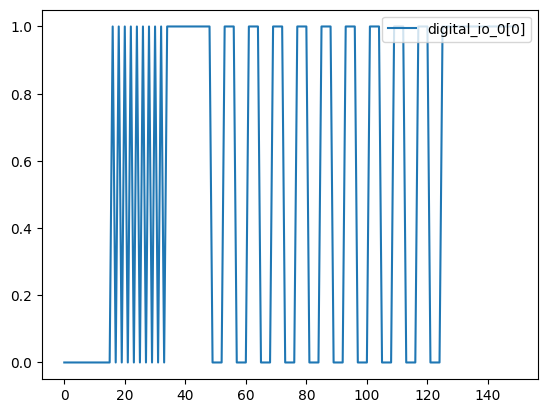

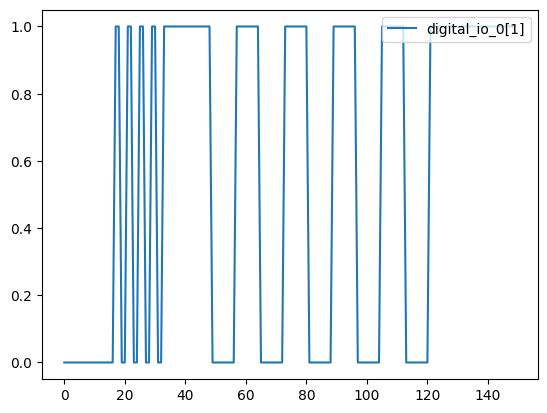

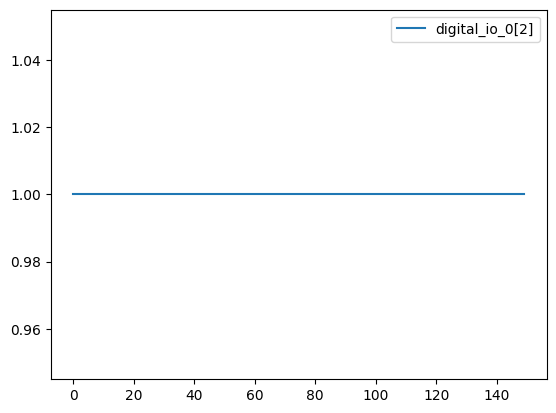

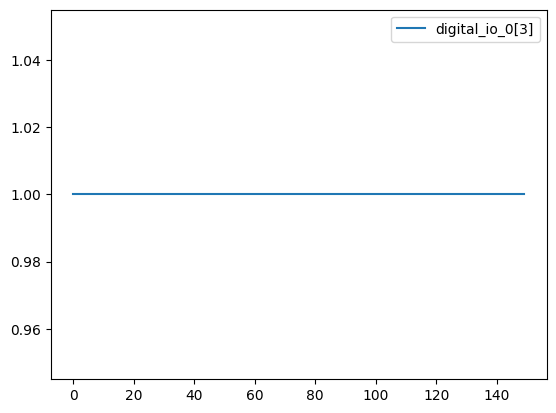

In [9]:
scope_dict = seq.get_scope()

for device_id in scope_dict.keys():
    for frame_label in scope_dict[device_id].keys():
        for scope_label in scope_dict[device_id][frame_label].keys():
            for acq_label in scope_dict[device_id][frame_label][scope_label].keys():
                t = scope_dict[device_id][frame_label][scope_label][acq_label]["t"]
                dec = scope_dict[device_id][frame_label][scope_label][acq_label]["dec"]
                samples = scope_dict[device_id][frame_label][scope_label][acq_label]["samples"]
                src = scope_dict[device_id][frame_label][scope_label][acq_label]["src"]
                data = scope_dict[device_id][frame_label][scope_label][acq_label]["data"]
                print(f"Device: {device_id}")
                print(f"Frame: {frame_label}")
                print(f"Scope: {scope_label}")
                print(f"Label: {acq_label}")
                print(f"Time: {t}")
                print(f"Decimation: {dec}")
                print(f"Samples: {samples}")
                print(f"Source: {src}")
                
                for i in range(4):
                    plt.figure()
                    plt.plot(((data >> i ) & 1), label= f"digital_io_0[{i}]")
                    plt.legend(loc=1)
                    plt.show()
        